### 1.3.5.5. Gradient and Level Sets

$$
\nabla f(\mathbf{x}) \perp \{\,\mathbf{x} : f(\mathbf{x}) = c\,\}
\qquad\text{(the gradient is normal to the level set through } \mathbf{x}\text{)} .
$$

**Explanation:**

Along a [level set](./01_functions_of_several_variables.ipynb) the value of $f$ does not change, so the directional derivative tangent to the level set is zero — which by $D_{\mathbf{u}}f = \nabla f \cdot \mathbf{u}$ forces the [gradient](./03_gradient.ipynb) to be orthogonal to the level set. Equivalently, steepest ascent always heads *across* the contours, perpendicular to them, never along them. This geometry explains why gradient descent paths cut contours at right angles and is the picture behind the [tangency condition](../../../03_Optimization/05_Nonlinear_Programming/02_equality_constraint_lagrange_multiplier_theorem.ipynb) of constrained optimization, where objective and constraint gradients align.

**Properties:**
- Parameterizing a level curve as $(x(t), y(t))$ and differentiating $f(x(t),y(t)) = c$ gives $\nabla f \cdot \langle x', y'\rangle = 0$.
- The gradient points from lower contours toward higher ones (uphill).

**Numerical Example:**

For $f(x,y) = x^2 + y^2$, the level set through $(1, 2)$ is the circle $x^2 + y^2 = 5$. Parameterize it as $(\sqrt5\cos t, \sqrt5\sin t)$; the tangent vector is $\langle -\sqrt5\sin t, \sqrt5\cos t\rangle$. At $(1,2)$ (where $\cos t = 1/\sqrt5,\ \sin t = 2/\sqrt5$) the tangent is $\langle -2, 1\rangle$, and

$$
\nabla f(1,2)\cdot\langle -2, 1\rangle = [2, 4]\cdot[-2, 1] = -4 + 4 = 0 .
$$

The gradient $[2,4]$ is perpendicular to the circle's tangent — it points radially outward, directly across the contour.

In [1]:
import sympy as sp

x, y = sp.symbols("x y")
f = x**2 + y**2

gradient_at_point = sp.Matrix([sp.diff(f, x), sp.diff(f, y)]).subs({x: 1, y: 2})
level_curve_tangent = sp.Matrix([-2, 1])
orthogonality_check = gradient_at_point.dot(level_curve_tangent)

print("∇f(1,2)                       =", gradient_at_point.T)
print("level-curve tangent at (1,2)  =", level_curve_tangent.T)
print("∇f · tangent (should be 0)    =", orthogonality_check)

∇f(1,2)                       = Matrix([[2, 4]])
level-curve tangent at (1,2)  = Matrix([[-2, 1]])
∇f · tangent (should be 0)    = 0


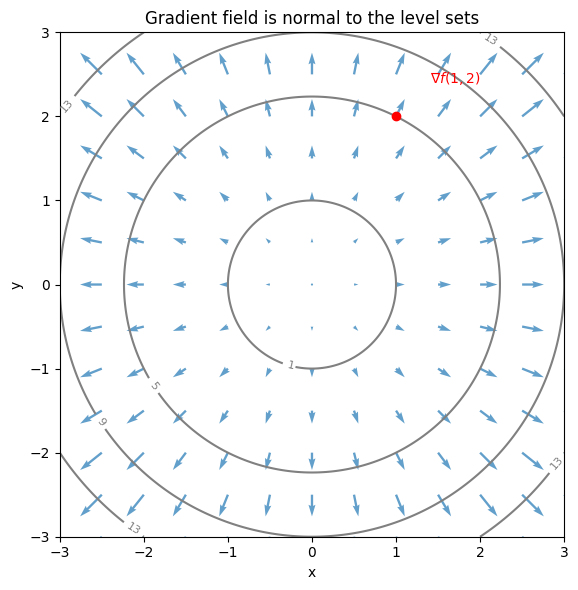

In [2]:
import numpy as np
import matplotlib.pyplot as plt

grid_axis = np.linspace(-3, 3, 200)
mesh_x, mesh_y = np.meshgrid(grid_axis, grid_axis)
field = mesh_x**2 + mesh_y**2

arrow_axis = np.linspace(-3, 3, 13)
arrow_x, arrow_y = np.meshgrid(arrow_axis, arrow_axis)
gradient_x, gradient_y = 2 * arrow_x, 2 * arrow_y

plt.figure(figsize=(7, 6))
contour = plt.contour(mesh_x, mesh_y, field, levels=[1, 5, 9, 13], colors="gray")
plt.clabel(contour, inline=True, fontsize=8)
plt.quiver(arrow_x, arrow_y, gradient_x, gradient_y, color="C0", alpha=0.7)
plt.scatter([1], [2], color="red", zorder=5)
plt.annotate(r"$\nabla f(1,2)$", (1, 2), (1.4, 2.4), color="red")
plt.title("Gradient field is normal to the level sets")
plt.xlabel("x"); plt.ylabel("y"); plt.gca().set_aspect("equal"); plt.tight_layout()
plt.show()

**References:**

[📘 Strang, G. (2016). *Calculus Volume 3*. OpenStax.](https://openstax.org/details/books/calculus-volume-3)

---

[⬅️ Previous: Directional Derivative](./04_directional_derivative.ipynb) | [Next: Linearization and the Tangent Plane ➡️](./06_linearization_and_tangent_plane.ipynb)